# Análise Exploratória de Dados: Empreendedorismo em Santa Catarina

**Desafio Prático de Dados/IA — Programa SCTEC — Trilha IA para DEVs**

Este notebook realiza tratamento e análise exploratória de dados relacionados ao empreendedorismo no estado de Santa Catarina.

## 1. Configuração do ambiente e carregamento dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Caminho dos dados: rodando de notebooks/ ou da raiz do projeto
DATA_PATH = Path("../data/empreendedorismo_sc.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/empreendedorismo_sc.csv")

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
print("Dados carregados.")
df.head(10)

Dados carregados.


,municipio,setor,ano_abertura,quantidade_empresas,mei,empregos_formais,faturamento_medio_mil_reais,sobrevivencia_1_ano,regiao
0,Itajaí,Comércio varejista,2023,42,True,68,11.60,87.1,Vale do Itajaí
1,Caçador,Serviços pessoais,2023,35,False,60,36.34,76.1,Oeste
2,Concórdia,Tecnologia da informação,2021,18,False,137,0.28,71.9,Oeste
3,Balneário Camboriú,Comércio varejista,2024,17,True,49,0.38,78.7,Vale do Itajaí
4,Jaraguá do Sul,Transporte e logística,2022,24,True,2,12.36,90.1,Norte
5,Itajaí,Educação,2025,3,True,106,1.87,83.8,Vale do Itajaí
6,Araranguá,Tecnologia da informação,2018,32,False,112,5.72,65.5,Sul
7,Balneário Camboriú,Tecnologia da informação,2024,35,False,93,20.69,69.9,Vale do Itajaí
8,Balneário Camboriú,Serviços pessoais,2018,38,False,117,81.12,81.9,Vale do Itajaí
9,São José,Construção civil,2025,13,True,197,42.44,65.8,Grande Florianópolis


## 2. Visão geral e identificação de problemas

In [2]:
print("Dimensões:", df.shape)
print("\nTipos e valores ausentes:")
df.info()
print("\nValores ausentes por coluna:")
print(df.isnull().sum())
print("\nResumo estatístico:")
df.describe(include="all")

Dimensões: (520, 9)

Tipos e valores ausentes:
<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   municipio                    520 non-null    str    
 1   setor                        520 non-null    str    
 2   ano_abertura                 520 non-null    int64  
 3   quantidade_empresas          520 non-null    int64  
 4   mei                          520 non-null    bool   
 5   empregos_formais             520 non-null    int64  
 6   faturamento_medio_mil_reais  485 non-null    float64
 7   sobrevivencia_1_ano          492 non-null    float64
 8   regiao                       520 non-null    str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 33.1 KB

Valores ausentes por coluna:
municipio                       0
setor                           0
ano_abertura                    0
quantidade_empresas   

,municipio,setor,ano_abertura,quantidade_empresas,mei,empregos_formais,faturamento_medio_mil_reais,sobrevivencia_1_ano,regiao
count,520,520,520.000000,520.000000,520,520.000000,485.000000,492.000000,520
unique,20,10,NaN,NaN,2,NaN,NaN,NaN,6
top,Blumenau,Comércio varejista,NaN,NaN,True,NaN,NaN,NaN,Vale do Itajaí
freq,36,62,NaN,NaN,310,NaN,NaN,NaN,166
mean,NaN,NaN,2021.444231,24.471154,NaN,98.998077,50.535381,79.597764,NaN
std,NaN,NaN,2.313728,14.161304,NaN,58.873611,50.983117,12.199555,NaN
min,NaN,NaN,2018.000000,0.000000,NaN,-1.000000,0.010000,27.400000,NaN
25%,NaN,NaN,2019.000000,12.000000,NaN,49.750000,15.050000,71.875000,NaN
50%,NaN,NaN,2022.000000,25.000000,NaN,100.500000,33.440000,81.850000,NaN
75%,NaN,NaN,2023.000000,37.000000,NaN,151.000000,70.570000,88.825000,NaN


## 3. Tratamento de valores inconsistentes e ausentes

In [3]:
# Cópia para não alterar o original
df_limpo = df.copy()

# Valores inconsistentes: empregos_formais não pode ser negativo
inválidos_empregos = (df_limpo["empregos_formais"] < 0).sum()
df_limpo.loc[df_limpo["empregos_formais"] < 0, "empregos_formais"] = 0
print(f"Corrigidos {inválidos_empregos} registros com empregos_formais negativos (substituídos por 0).")

# quantidade_empresas = 0 não faz sentido para análise de empreendedorismo ativo
zeros_empresas = (df_limpo["quantidade_empresas"] == 0).sum()
df_limpo = df_limpo[df_limpo["quantidade_empresas"] > 0].copy()
print(f"Removidos {zeros_empresas} registros com quantidade_empresas = 0.")

# Valores ausentes: preencher numéricos com mediana (menos sensível a outliers)
for col in ["faturamento_medio_mil_reais", "sobrevivencia_1_ano"]:
    mediana = df_limpo[col].median()
    n_antes = df_limpo[col].isnull().sum()
    df_limpo[col] = df_limpo[col].fillna(mediana)
    print(f"Preenchidos {n_antes} valores ausentes em '{col}' com mediana = {mediana:.2f}.")

print(f"\nShape após limpeza: {df_limpo.shape}")
df_limpo.head()

Corrigidos 15 registros com empregos_formais negativos (substituídos por 0).
Removidos 10 registros com quantidade_empresas = 0.
Preenchidos 34 valores ausentes em 'faturamento_medio_mil_reais' com mediana = 33.50.
Preenchidos 28 valores ausentes em 'sobrevivencia_1_ano' com mediana = 82.10.

Shape após limpeza: (510, 9)


,municipio,setor,ano_abertura,quantidade_empresas,mei,empregos_formais,faturamento_medio_mil_reais,sobrevivencia_1_ano,regiao
0,Itajaí,Comércio varejista,2023,42,True,68,11.60,87.1,Vale do Itajaí
1,Caçador,Serviços pessoais,2023,35,False,60,36.34,76.1,Oeste
2,Concórdia,Tecnologia da informação,2021,18,False,137,0.28,71.9,Oeste
3,Balneário Camboriú,Comércio varejista,2024,17,True,49,0.38,78.7,Vale do Itajaí
4,Jaraguá do Sul,Transporte e logística,2022,24,True,2,12.36,90.1,Norte


## 4. Organização das informações

In [4]:
df_limpo["mei"] = df_limpo["mei"].astype(bool)
df_limpo["ano_abertura"] = df_limpo["ano_abertura"].astype(int)
df_organizado = df_limpo.sort_values(["regiao", "setor", "ano_abertura"]).reset_index(drop=True)
print("Dados organizados por região, setor e ano.")
df_organizado.head(10)

Dados organizados por região, setor e ano.


,municipio,setor,ano_abertura,quantidade_empresas,mei,empregos_formais,faturamento_medio_mil_reais,sobrevivencia_1_ano,regiao
0,São José,Agricultura e pecuária,2018,31,True,15,26.14,84.2,Grande Florianópolis
1,Florianópolis,Agricultura e pecuária,2022,16,True,7,156.23,87.2,Grande Florianópolis
2,Florianópolis,Agricultura e pecuária,2023,24,True,196,197.48,94.2,Grande Florianópolis
3,São José,Agricultura e pecuária,2023,3,False,63,142.99,27.4,Grande Florianópolis
4,Florianópolis,Agricultura e pecuária,2025,45,True,51,15.43,84.6,Grande Florianópolis
5,São José,Agricultura e pecuária,2025,43,True,34,7.95,74.7,Grande Florianópolis
6,Florianópolis,Comércio varejista,2018,8,True,3,17.80,77.8,Grande Florianópolis
7,Florianópolis,Comércio varejista,2018,20,True,161,25.97,82.5,Grande Florianópolis
8,Florianópolis,Comércio varejista,2020,10,True,175,80.07,82.1,Grande Florianópolis
9,Florianópolis,Comércio varejista,2021,13,True,57,58.30,70.9,Grande Florianópolis


## 5. Análise exploratória e métricas

In [5]:
print("=== Empreendedorismo por setor (total de empresas) ===")
por_setor = df_organizado.groupby("setor")["quantidade_empresas"].sum().sort_values(ascending=False)
print(por_setor)

print("\n=== Empreendedorismo por região (média de empregos formais) ===")
por_regiao = df_organizado.groupby("regiao")["empregos_formais"].agg(["mean", "sum"]).round(2)
print(por_regiao)

print("\n=== Proporção MEI por setor (%) ===")
mei_por_setor = df_organizado.groupby("setor")["mei"].mean() * 100
print(mei_por_setor.round(1))

=== Empreendedorismo por setor (total de empresas) ===
setor
Serviços pessoais           1639
Comércio varejista          1537
Indústria de confecções     1533
Construção civil            1366
Tecnologia da informação    1245
Educação                    1216
Saúde                       1173
Agricultura e pecuária      1143
Serviços de alimentação     1013
Transporte e logística       860
Name: quantidade_empresas, dtype: int64

=== Empreendedorismo por região (média de empregos formais) ===
                        mean    sum
regiao                             
Grande Florianópolis  101.49   8119
Norte                 100.29   6820
Oeste                 100.00   6500
Serra                 100.57   5330
Sul                   105.23   8208
Vale do Itajaí         94.41  15672

=== Proporção MEI por setor (%) ===
setor
Agricultura e pecuária      62.7
Comércio varejista          67.7
Construção civil            68.6
Educação                    54.3
Indústria de confecções     60.3
Saúde   

## 6. Visualizações

C:\Users\giova\AppData\Local\Temp\ipykernel_13952\416682008.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_organizado, x="setor", y="sobrevivencia_1_ano", ax=axes[1, 1], palette="muted")


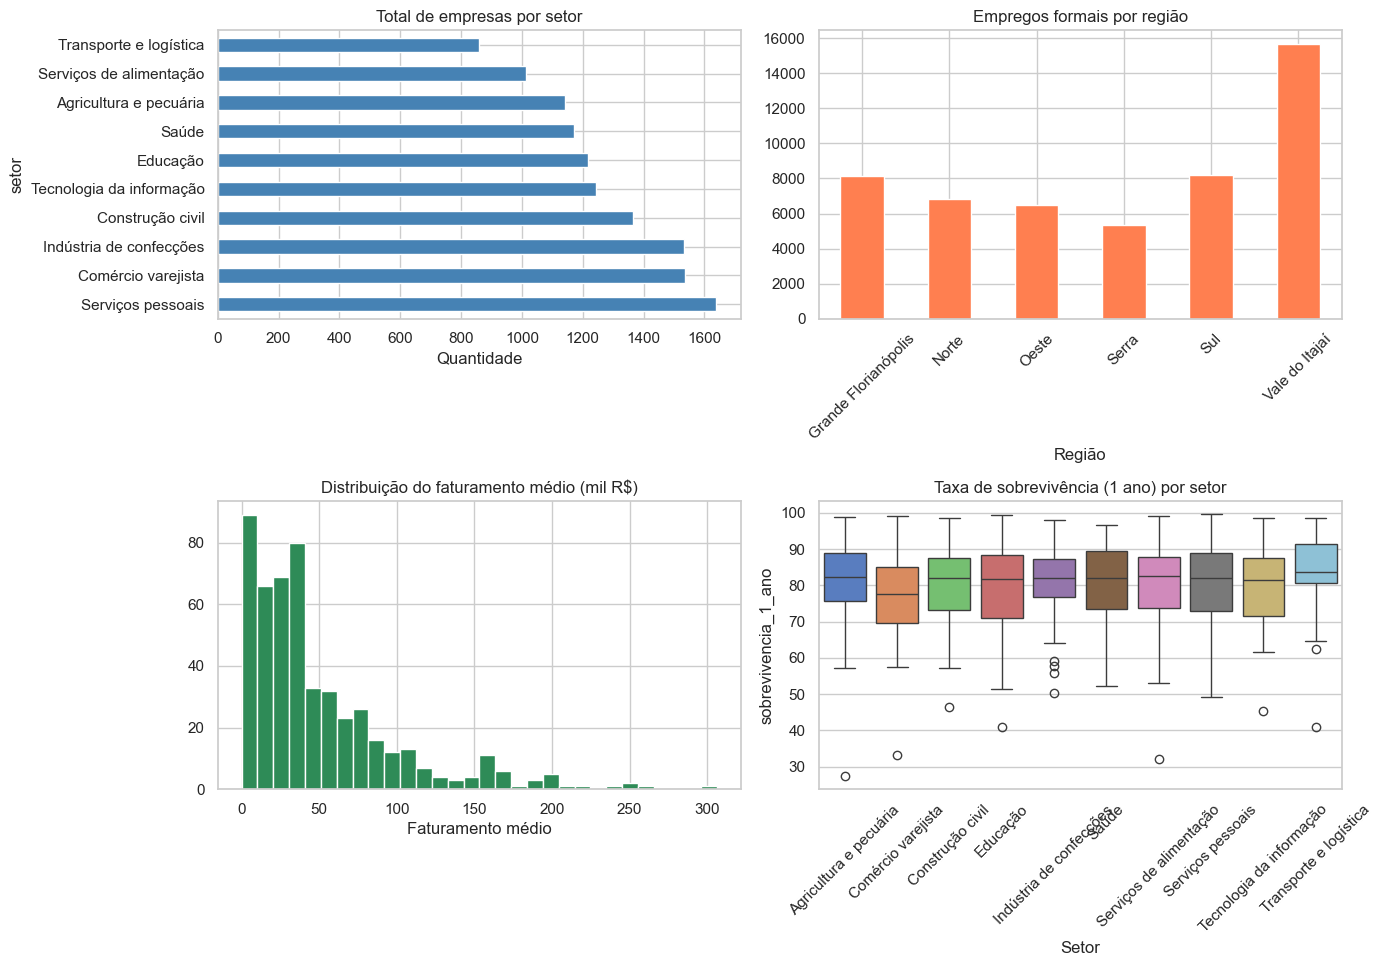

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Quantidade de empresas por setor
por_setor.plot(kind="barh", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Total de empresas por setor")
axes[0, 0].set_xlabel("Quantidade")

# Gráfico 2: Empregos formais por região
df_organizado.groupby("regiao")["empregos_formais"].sum().plot(kind="bar", ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Empregos formais por região")
axes[0, 1].set_xlabel("Região")
axes[0, 1].tick_params(axis="x", rotation=45)

# Gráfico 3: Distribuição do faturamento médio
df_organizado["faturamento_medio_mil_reais"].hist(bins=30, ax=axes[1, 0], color="seagreen", edgecolor="white")
axes[1, 0].set_title("Distribuição do faturamento médio (mil R$)")
axes[1, 0].set_xlabel("Faturamento médio")

# Gráfico 4: Sobrevivência 1 ano por setor (boxplot)
sns.boxplot(data=df_organizado, x="setor", y="sobrevivencia_1_ano", ax=axes[1, 1], palette="muted")
axes[1, 1].set_title("Taxa de sobrevivência (1 ano) por setor")
axes[1, 1].set_xlabel("Setor")
axes[1, 1].tick_params(axis="x", rotation=45)
plt.suptitle("")
plt.tight_layout()
plt.show()

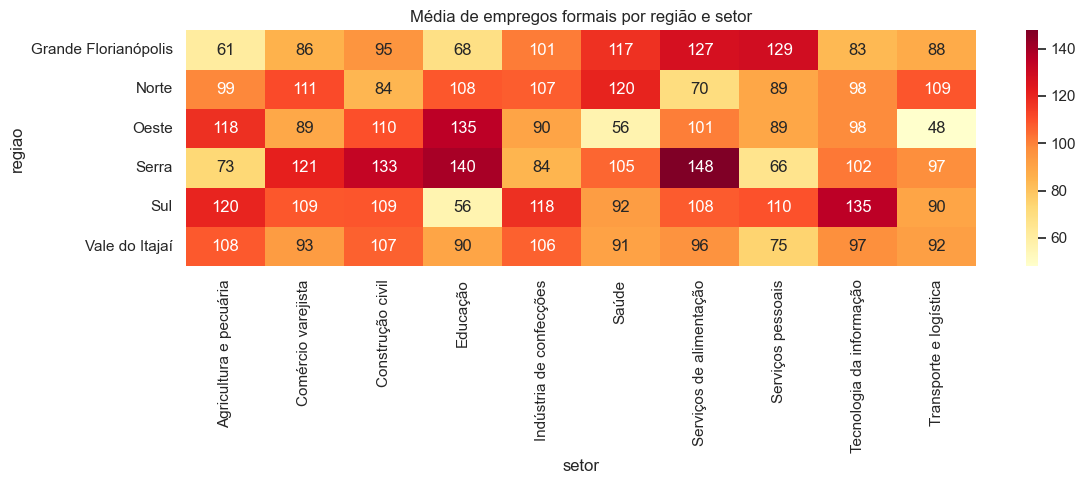

In [7]:
# Heatmap: empregos por região e setor (média)
tabela = df_organizado.pivot_table(
    values="empregos_formais", index="regiao", columns="setor", aggfunc="mean"
).round(1)
plt.figure(figsize=(12, 5))
sns.heatmap(tabela, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Média de empregos formais por região e setor")
plt.tight_layout()
plt.show()

## 7. Conclusões da análise

In [8]:
print("RESUMO DA ANÁLISE - Empreendedorismo em Santa Catarina")
print("-" * 50)
print(f"Total de registros analisados: {len(df_organizado)}")
print(f"Municípios contemplados: {df_organizado['municipio'].nunique()}")
print(f"Setores de atividade: {df_organizado['setor'].nunique()}")
print(f"Proporção de MEI: {df_organizado['mei'].mean()*100:.1f}%")
print(f"Faturamento médio geral (mil R$): {df_organizado['faturamento_medio_mil_reais'].mean():.2f}")
print(f"Sobrevivência média 1 ano: {df_organizado['sobrevivencia_1_ano'].mean():.1f}%")
print("-" * 50)
print("A solução atende ao escopo do desafio: carregamento, tratamento de")
print("inconsistências e ausentes, organização e análise com tabelas e gráficos.")

RESUMO DA ANÁLISE - Empreendedorismo em Santa Catarina
--------------------------------------------------
Total de registros analisados: 510
Municípios contemplados: 20
Setores de atividade: 10
Proporção de MEI: 59.8%
Faturamento médio geral (mil R$): 49.45
Sobrevivência média 1 ano: 79.9%
--------------------------------------------------
A solução atende ao escopo do desafio: carregamento, tratamento de
inconsistências e ausentes, organização e análise com tabelas e gráficos.
